In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
weighted_returns_df = pd.read_csv("data/outputs/baseline_portfolio",
                                  index_col = 0, parse_dates = [1])
daily_df_annually = pd.read_csv("data/outputs/annually_reblanced_portfolio",
                                index_col = 0, parse_dates = [1])
daily_df_quarterly = pd.read_csv("data/outputs/quarterly_reblanced_portfolio",
                                 index_col = 0, parse_dates = [1])
daily_df_quarterly_band = pd.read_csv("data/outputs/quarterly_reblanced_byband_portfolio", 
                                      index_col = 0, parse_dates = [1])
annual_weights_frame = pd.read_csv("data/outputs/annually_rebalanced_weights",
                                index_col = 0, parse_dates=[1])
quarterly_weights_frame= pd.read_csv("data/outputs/quarterly_rebalanced_weights",
                                index_col = 0, parse_dates=[1])
band_weights_frame = pd.read_csv("data/outputs/quarterly_rebalanced_byband_weights",
                                index_col = 0, parse_dates=[1])

In [166]:
## Portfolio Drift ##


def drift_evaluation(df):
    starting_weights = df[df["weight_type"] == "starting"]
    ending_weights = df[df["weight_type"] == "ending"]

    difference = np.array(ending_weights.drop(columns=['Date','weight_type'])) - np.array(starting_weights.drop(columns=['Date','weight_type']))

    drift_list = []

    for period in range(len(difference)):
        start_date = starting_weights['Date'].iloc[period]
        end_date = ending_weights['Date'].iloc[period]

        drift = abs(difference[period]).sum()
        drift_list.append({
            "Start": start_date,
            "End" : end_date,
            "Drift": drift
            })

    return pd.DataFrame(drift_list)


In [167]:
annual_drift = drift_evaluation(annual_weights_frame)
quarterly_drift = drift_evaluation(quarterly_weights_frame)
band_drift = drift_evaluation(band_weights_frame)


In [168]:
## Trades ##
def calculate_trades(df):
    starting_weights = df[df["weight_type"] == "starting"]
    ending_weights = df[df["weight_type"] == "ending"]
    starting_weights_next = starting_weights.drop(starting_weights.index[0])
    ending_weights_current = ending_weights.drop(ending_weights.index[-1])
    start = starting_weights_next.drop(columns=['Date','weight_type'])
    end = ending_weights_current.drop(columns=['Date','weight_type'])
    trades = np.array(start) - np.array(end)
    trades_df = pd.DataFrame(trades, index = starting_weights_next['Date'], columns = start.columns)
    return trades_df


In [169]:
annual_trades_df = calculate_trades(annual_weights_frame)
quarterly_trades = calculate_trades(quarterly_weights_frame)
band_trades = calculate_trades(band_weights_frame)

In [170]:
## Turnover ## 
def calculate_turnover(df):
    turnover_list = []
    for row in range(len(df.index)):
        turnover = abs(df.iloc[row]).sum(axis = 0) * 0.5
        turnover_list.append({
            'Date':df.index[row],
            'turnover': turnover
            })
    return pd.DataFrame(turnover_list)


In [171]:
annual_portfolio_turnover = calculate_turnover(annual_trades_df)
quarterly_portfolio_turnover = calculate_turnover(quarterly_trades)
band_portfolio_turnover = calculate_turnover(band_trades)

In [172]:
def value_analysis(df, turnover_df, bp):

    tc = bp/10000

    df = df.copy()
    gross_value = df['portfolio_value']
    df2 = df.drop(columns = 'portfolio_value')

    turnover_series = turnover_df.set_index('Date').squeeze()

    df2['turnover'] = df2['Date'].map(turnover_series)

    previous_value = 1.0

    for index, row in df2.iterrows():

        past_value = previous_value
        growth = 1 + row["portfolio_return"]
        value = past_value * growth

        turnover = row["turnover"]

        if row["Rebalanced"] == 1 and pd.notna(turnover):
            cost = value * tc * turnover
        else:
            cost = 0

        portfolio_value = value - cost

        df2.loc[index, "past_value"] = past_value
        df2.loc[index, "growth"] = growth
        df2.loc[index, "value"] = value
        df2.loc[index, "cost"] = cost
        df2.loc[index, "portfolio_value"] = portfolio_value

        previous_value = portfolio_value

    df2['gross_value'] = gross_value
    return df2


In [173]:
annual_value_adjusted = value_analysis(
    df = daily_df_annually,
    turnover_df=annual_portfolio_turnover,
    bp = 100
)
quarterly_value_adjusted = value_analysis(
    df = daily_df_quarterly,
    turnover_df=quarterly_portfolio_turnover,
    bp = 100
)
band_value_adjusted = value_analysis(
    df = daily_df_quarterly_band,
    turnover_df=band_portfolio_turnover,
    bp = 100
)

Text(2026-09-08 00:00:00, 1.46, '1.46')

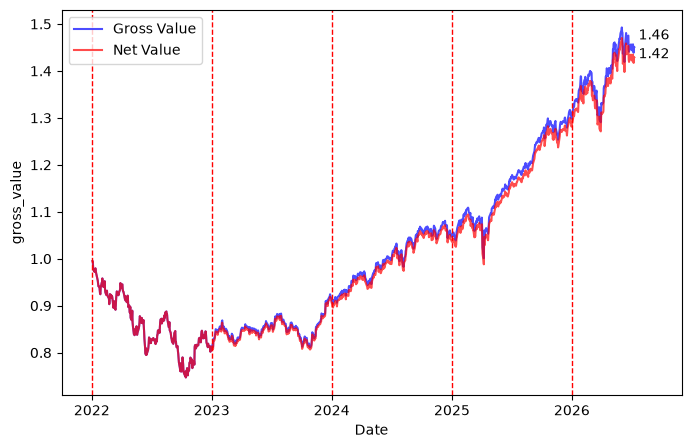

In [174]:
rebalance_days = annual_value_adjusted.loc[annual_value_adjusted['Rebalanced'] == 1, 'Date']
plt.figure(figsize= (8,5))

sns.lineplot(data = annual_value_adjusted, x = 'Date', y = 'gross_value', color='blue', label = "Gross Value", alpha = 0.7)
sns.lineplot(data = annual_value_adjusted, x = 'Date', y = 'portfolio_value', color = 'red', label = "Net Value", alpha = 0.7)

plt.legend()
for day in rebalance_days:
    plt.axvline(x=day, color="red", linestyle="--", linewidth=1)

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

x1 = annual_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y1 = annual_value_adjusted['portfolio_value'].iloc[-1].round(2) - 0.01

plt.text(
        x=x1,
        y=y1,  # Offset slightly above the marker
        s=f"{y1}",  # The string text to display
        ha="center",  # Center-align horizontally
        va="bottom",  # Align bottom of text to the coordinate
        fontsize=10,
        color="black",
    )

x2 = annual_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y2 = annual_value_adjusted['gross_value'].iloc[-1].round(2) + 0.01

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x2,
        y=y2,  # Offset slightly above the marker
        s=f"{y2}",  # The string text to display
        ha="center",  # Center-align horizontally
        va="bottom",  # Align bottom of text to the coordinate
        fontsize=10,
        color="black",
    )

In [175]:
quarterly_value_adjusted['portfolio_value'].tail(1)

1132    1.465306
Name: portfolio_value, dtype: float64

Text(2026-09-08 00:00:00, 1.53, '1.53')

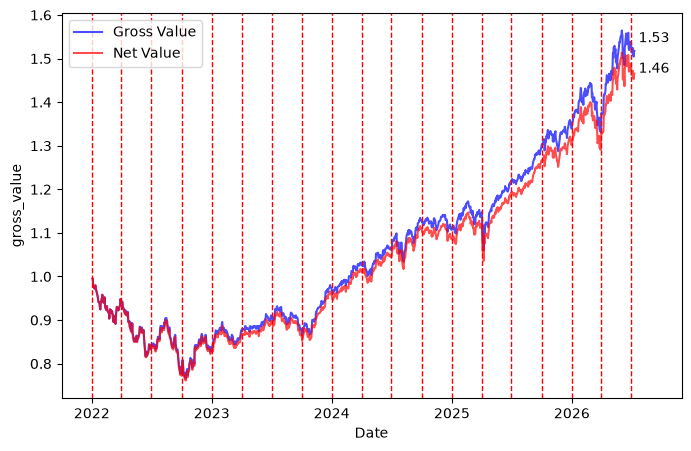

In [176]:
rebalance_days = quarterly_value_adjusted.loc[quarterly_value_adjusted['Rebalanced'] == 1, 'Date']
plt.figure(figsize= (8,5))

sns.lineplot(data = quarterly_value_adjusted, x = 'Date', y = 'gross_value', color='blue', label = "Gross Value", alpha = 0.7)
sns.lineplot(data = quarterly_value_adjusted, x = 'Date', y = 'portfolio_value', color = 'red', label = "Net Value", alpha = 0.7)

plt.legend()
for day in rebalance_days:
    plt.axvline(x=day, color="red", linestyle="--", linewidth=1)

x1 = quarterly_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y1 = quarterly_value_adjusted['portfolio_value'].iloc[-1].round(2) - 0.01

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x1,
        y=y1,  # Offset slightly above the marker
        s=f"{y1}",  # The string text to display
        ha="center",  # Center-align horizontally
        va="bottom",  # Align bottom of text to the coordinate
        fontsize=10,
        color="black",
    )

x2 = quarterly_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y2 = quarterly_value_adjusted['gross_value'].iloc[-1].round(2) + 0.01

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x2,
        y=y2,  # Offset slightly above the marker
        s=f"{y2}",  # The string text to display
        ha="center",  # Center-align horizontally
        va="bottom",  # Align bottom of text to the coordinate
        fontsize=10,
        color="black",
    )

Text(2026-09-08 00:00:00, 1.53, '1.53')

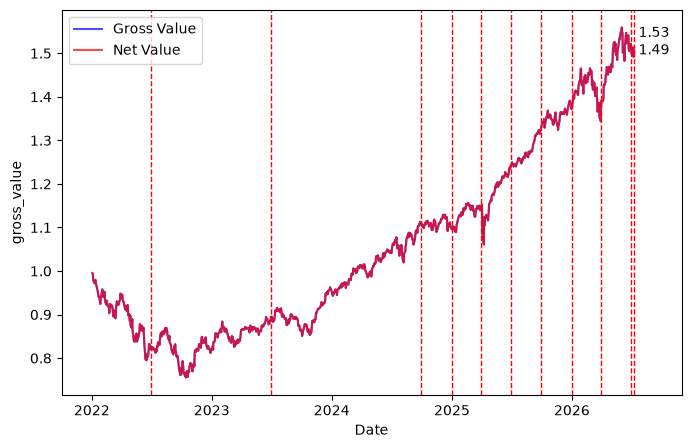

In [177]:
rebalance_days = band_value_adjusted.loc[band_value_adjusted['Rebalanced'] == 1, 'Date']
plt.figure(figsize= (8,5))

sns.lineplot(data = band_value_adjusted, x = 'Date', y = 'gross_value', color='blue', label = "Gross Value", alpha = 0.7)
sns.lineplot(data = band_value_adjusted, x = 'Date', y = 'portfolio_value', color = 'red', label = "Net Value", alpha = 0.7)

plt.legend()
for day in rebalance_days:
    plt.axvline(x=day, color="red", linestyle="--", linewidth=1)

x1 = band_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y1 = band_value_adjusted['portfolio_value'].iloc[-1].round(2) - 0.02

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x1,
        y=y1,  # Offset slightly above the marker
        s=f"{y1}",  # The string text to display
        ha="center",  # Center-align horizontally
        va="bottom",  # Align bottom of text to the coordinate
        fontsize=10,
        color="black",
    )

x2 = band_value_adjusted['Date'].iloc[-1] + pd.to_timedelta(60, unit='D')
y2 = band_value_adjusted['gross_value'].iloc[-1].round(2) + 0.02

plt.xlim(pd.to_datetime('2021-10-1'), pd.to_datetime('2026-12-1'))

plt.text(
        x=x2,
        y=y2,  # Offset slightly above the marker
        s=f"{y2}",  # The string text to display
        ha="center",  # Center-align horizontally
        va="bottom",  # Align bottom of text to the coordinate
        fontsize=10,
        color="black",
    )

## Weight Stability ## 
For each rebalance:

Compute turnover
T
Observe portfolio value before the rebalance
V
Assume transaction cost
c
Cost paid
Cost=V×T×c
New portfolio value
V
after
	​

=V−Cost

Holding Period Analysis

Questions

Average holding period

How often is each ETF traded?

Average position age

Number of consecutive quarters held